# Cyber Threat Detection — Hackathon Modeling Notebook
**Team: Agile Hawks | Neural Nexus Competition**

> **Strategy:** Ensemble of XGBoost .

### Pipeline Overview
1. Load engineered dataset (already scaled + encoded from feature engineering notebook)
2. Proper train/validation/test split (stratified)
3. Class imbalance handling via SMOTE on train only
4. Baseline models with cross-validation
5. XGBoost
6. Final evaluation + submission

##  1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import joblib
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Core ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalance
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)

# Paths — update if running locally
DATA_PATH      = '/kaggle/input/datasets/anshkarki/engineered-dataset-1/engineered_dataset.csv'
LABEL_MAP_PATH = '/kaggle/input/datasets/anshkarki/engineered-dataset-1/label_map.csv'
LABEL_COL      = 'Label'

print(' All imports successful')

✅ All imports successful


##  2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
label_map_df = pd.read_csv(LABEL_MAP_PATH)
label_map = dict(zip(label_map_df['encoded'], label_map_df['original']))

print(f'Dataset shape  : {df.shape}')
print(f'Label classes  : {df[LABEL_COL].nunique()}')
print(f'\nLabel mapping  :')
for k, v in sorted(label_map.items()):
    print(f'  {k:>2} → {v}')

# Sanity checks
assert df.isnull().sum().sum() == 0, '❌ Dataset has nulls — check feature engineering output!'
print(f'\n✅ No null values found')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset shape  : (1768131, 86)
Label classes  : 1589

Label mapping  :
   0 → ??
   1 → BBENIGN
   2 → BBot
   3 → BBot - Attempted
   4 → BEENIGN
   5 → BEIGN
   6 → BEINGN
   7 → BENGIN
   8 → BENGN
   9 → BENIG
  10 → BENIGGN
  11 → BENIGN
  12 → BENIGNN
  13 → BENIGaN
  14 → BENIGbN
  15 → BENIGcN
  16 → BENIGdN
  17 → BENIGeN
  18 → BENIGfN
  19 → BENIGgN
  20 → BENIGhN
  21 → BENIGiN
  22 → BENIGjN
  23 → BENIGkN
  24 → BENIGlN
  25 → BENIGmN
  26 → BENIGnN
  27 → BENIGoN
  28 → BENIGpN
  29 → BENIGqN
  30 → BENIGrN
  31 → BENIGsN
  32 → BENIGtN
  33 → BENIGuN
  34 → BENIGvN
  35 → BENIGwN
  36 → BENIGxN
  37 → BENIGyN
  38 → BENIGzN
  39 → BENIIGN
  40 → BENIN
  41 → BENING
  42 → BENIaGN
  43 → BENIbGN
  44 → BENIcGN
  45 → BENIdGN
  46 → BENIeGN
  47 → BENIfGN
  48 → BENIgGN
  49 → BENIhGN
  50 → BENIiGN
  51 → BENIjGN
  52 → BENIkGN
  53 → BENIlGN
  54 → BENImGN
  55 → BENInGN
  56 → BENIoGN
  57 → BENIpGN
  58 → BENIqGN
  59 → BENIrGN
  60 → BENIsGN
  61 → BENItGN
  62 → BEN

In [3]:
# === KEEP ONLY TOP K CLASSES (CRITICAL FIX) ===
TOP_K = 20

class_counts = df[LABEL_COL].value_counts()
top_classes = class_counts.nlargest(TOP_K).index
df = df[df[LABEL_COL].isin(top_classes)].copy()

print(f"✅ Reduced to top {TOP_K} classes")
print(df[LABEL_COL].value_counts())

# === OPTIONAL SAFETY FILTER ===
MIN_SAMPLES = 30
counts = df[LABEL_COL].value_counts()
df = df[df[LABEL_COL].map(counts) >= MIN_SAMPLES].copy()

print(f"\n✅ After min sample filter (≥{MIN_SAMPLES})")
print(df[LABEL_COL].value_counts())

# === UPDATE LABEL MAP (IMPORTANT) ===
label_map = {k: v for k, v in label_map.items() if k in df[LABEL_COL].unique()}


le = LabelEncoder()
df[LABEL_COL] = le.fit_transform(df[LABEL_COL])
label_map = {i: label for i, label in enumerate(le.classes_)}
# === RECREATE X, y ===
y = df[LABEL_COL].values
X = df.drop(columns=[LABEL_COL]).values
feature_names = df.drop(columns=[LABEL_COL]).columns.tolist()

# === VERIFY ===
unique, counts = np.unique(y, return_counts=True)
print("\nMin class count:", np.min(counts))
assert np.min(counts) >= MIN_SAMPLES, "Still unsafe!"

print("✅ Dataset is now SAFE for splitting")

✅ Reduced to top 20 classes
Label
11      1173236
1088     134265
409      113817
246       80303
1416      38943
131       19737
12         7828
41         3999
9          3959
916        3945
4          3937
1          3936
40         3928
6          3919
5          3911
39         3894
121        3892
8          3888
915        3875
68         3851
Name: count, dtype: int64

✅ After min sample filter (≥30)
Label
11      1173236
1088     134265
409      113817
246       80303
1416      38943
131       19737
12         7828
41         3999
9          3959
916        3945
4          3937
1          3936
40         3928
6          3919
5          3911
39         3894
121        3892
8          3888
915        3875
68         3851
Name: count, dtype: int64

Min class count: 3851
✅ Dataset is now SAFE for splitting


##  3. Exploratory Analysis

Features : 85
Samples  : 1,619,063



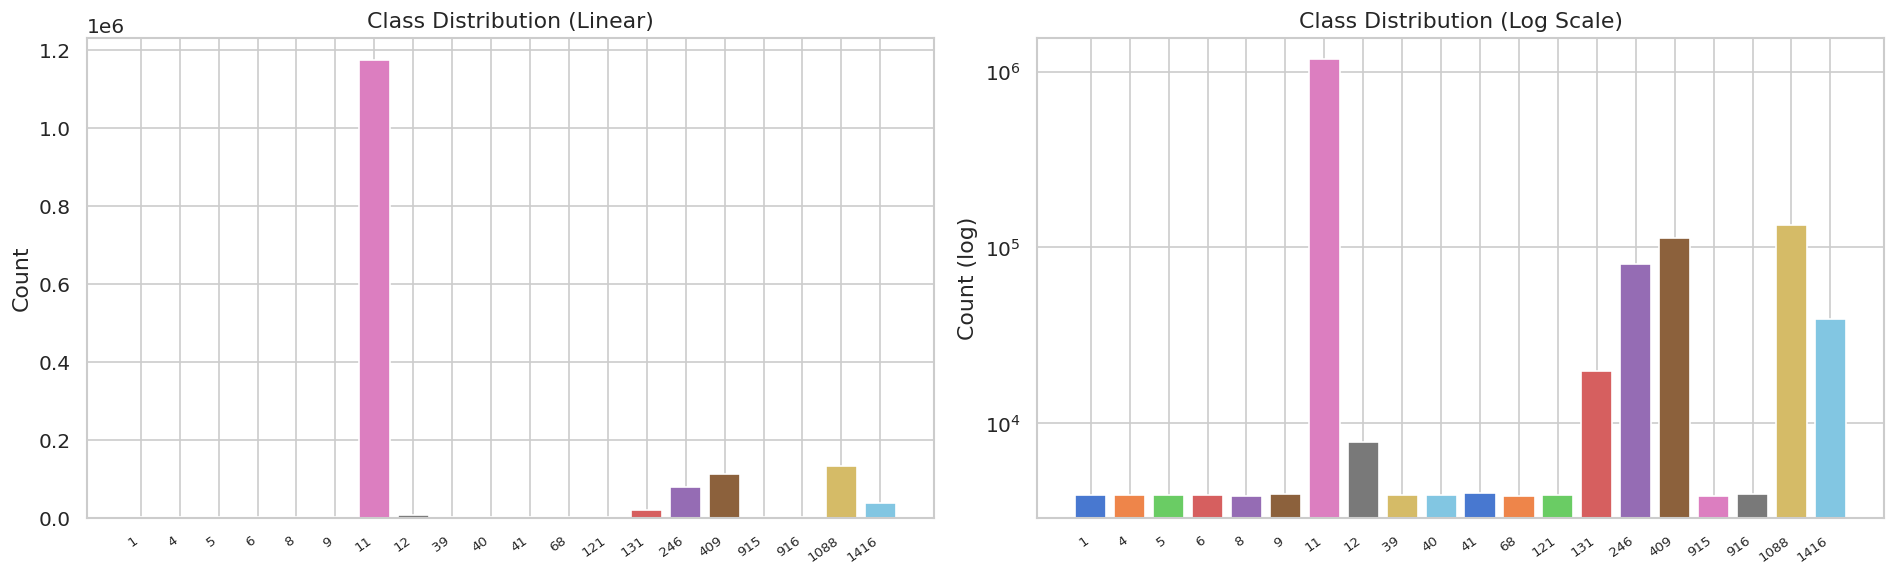

Imbalance ratio (majority/minority): 305x

Class counts:
   0 | 1                              |    3,936  (0.24%)
   1 | 4                              |    3,937  (0.24%)
   2 | 5                              |    3,911  (0.24%)
   3 | 6                              |    3,919  (0.24%)
   4 | 8                              |    3,888  (0.24%)
   5 | 9                              |    3,959  (0.24%)
   6 | 11                             | 1,173,236  (72.46%)
   7 | 12                             |    7,828  (0.48%)
   8 | 39                             |    3,894  (0.24%)
   9 | 40                             |    3,928  (0.24%)
  10 | 41                             |    3,999  (0.25%)
  11 | 68                             |    3,851  (0.24%)
  12 | 121                            |    3,892  (0.24%)
  13 | 131                            |   19,737  (1.22%)
  14 | 246                            |   80,303  (4.96%)
  15 | 409                            |  113,817  (7.03%)
  16 | 915   

In [4]:


print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}\n')

# Class distribution
class_counts = pd.Series(y).value_counts().sort_index()
class_labels = [label_map[i] for i in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear scale
axes[0].bar(range(len(class_counts)), class_counts.values,
            color=sns.color_palette('muted', len(class_counts)))
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_labels, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Class Distribution (Linear)')
axes[0].set_ylabel('Count')

# Log scale
axes[1].bar(range(len(class_counts)), class_counts.values,
            color=sns.color_palette('muted', len(class_counts)))
axes[1].set_yscale('log')
axes[1].set_xticks(range(len(class_counts)))
axes[1].set_xticklabels(class_labels, rotation=35, ha='right', fontsize=8)
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# Imbalance ratio
majority = class_counts.max()
minority = class_counts.min()
print(f'Imbalance ratio (majority/minority): {majority/minority:.0f}x')
print('\nClass counts:')
for enc, lbl, cnt in zip(class_counts.index, class_labels, class_counts.values):
    pct = cnt / len(y) * 100
    print(f'  {enc:>2} | {lbl:<30} | {cnt:>8,}  ({pct:.2f}%)')

##  4. Stratified Train / Validation / Test Split
> **Important:** Splitting BEFORE any imbalance handling to prevent data leakage.

In [5]:
# 70% train | 15% val | 15% test  — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {X_train.shape[0]:>8,} samples ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'Val   : {X_val.shape[0]:>8,} samples ({X_val.shape[0]/len(y)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]:>8,} samples ({X_test.shape[0]/len(y)*100:.1f}%)')

# Verify stratification held
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    assert len(unique) == len(label_map), f'{split_name} is missing some classes!'
print('\n✅ All classes present in every split')

Train : 1,133,344 samples (70.0%)
Val   :  242,859 samples (15.0%)
Test  :  242,860 samples (15.0%)

✅ All classes present in every split


##  5. Handle Class Imbalance with SMOTE
> Applied **only on training data** to avoid leakage.

In [6]:
from collections import Counter

# Correct class counts
class_counts = Counter(y_train)
min_class_size = min(class_counts.values())

k_neighbors = min(5, min_class_size - 1)

print(f'Minimum class count in train: {min_class_size}')
print(f'Using k_neighbors = {k_neighbors} for SMOTE')

if min_class_size < 6:
    print('⚠️  Too few minority samples for SMOTE → will use class_weight="balanced" in models')
    X_train_resampled, y_train_resampled = X_train, y_train
    USE_SMOTE = False
else:
    print('Applying SMOTETomek...')
    
    t0 = time.time()
    
    max_count = max(class_counts.values())
    target_count = max_count // 3
    
    sampling_strategy = {
        cls: max(cnt, min(target_count, cnt * 5))
        for cls, cnt in class_counts.items()
        if cnt < target_count
    }
    
    if sampling_strategy:
        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=k_neighbors,
            random_state=SEED,
        )
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    else:
        X_train_resampled, y_train_resampled = X_train, y_train
    
    print(f'Train before SMOTE : {len(y_train):,}')
    print(f'Train after SMOTE  : {len(y_train_resampled):,}')
    
    USE_SMOTE = True

Minimum class count in train: 2696
Using k_neighbors = 5 for SMOTE
Applying SMOTETomek...
Train before SMOTE : 1,133,344
Train after SMOTE  : 2,053,580


##  6. Helper Functions

In [7]:
def evaluate_model(model, X_eval, y_eval, split_name='Validation', show_cm=False):
    y_pred = model.predict(X_eval)

    acc   = accuracy_score(y_eval, y_pred)
    f1_mac = f1_score(y_eval, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_eval, y_pred, average='weighted', zero_division=0)
    prec   = precision_score(y_eval, y_pred, average='macro', zero_division=0)
    rec    = recall_score(y_eval, y_pred, average='macro', zero_division=0)

    print(f'\n── {split_name} Results ─────────────────────────')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  F1 Macro        : {f1_mac:.4f}  ← PRIMARY')
    print(f'  F1 Weighted     : {f1_wt:.4f}')
    print(f'  Precision Macro : {prec:.4f}')
    print(f'  Recall Macro    : {rec:.4f}')
    print()

    # ✅ SAFE classification report
    labels_sorted = sorted(np.unique(y_eval))

    print(classification_report(
        y_eval,
        y_pred,
        labels=labels_sorted,
        target_names=[str(label_map[i]) for i in labels_sorted],
        zero_division=0
    ))

    return {'acc': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wt}

In [10]:
from collections import Counter

class_counts = Counter(y_train_resampled)

class_weights = {
    cls: len(y_train_resampled) / (len(class_counts) * cnt)
    for cls, cnt in class_counts.items()
}

In [11]:
from collections import Counter
import numpy as np

print("⚖️ Computing class weights...")

counts = Counter(y_train_resampled)

class_weights = {
    cls: len(y_train_resampled) / (len(counts) * cnt)
    for cls, cnt in counts.items()
}

sample_weights_train = np.array([class_weights[c] for c in y_train_resampled])

print("✅ Sample weights ready")

⚖️ Computing class weights...
✅ Sample weights ready


In [13]:
print('🚀 Retraining XGBoost (with class weights)...')
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=800,              # reduced for speed
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    n_jobs=-1,
    random_state=SEED,
    early_stopping_rounds=20,      # faster stop
    verbosity=0
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

print(f"\n⏱️ Training time: {time.time()-t0:.1f}s")
print(f"Best iteration: {xgb_model.best_iteration}")

xgb_results = evaluate_model(xgb_model, X_val, y_val, 'XGBoost (Weighted)')

🚀 Retraining XGBoost (with class weights)...
[0]	validation_0-mlogloss:2.78152
[1]	validation_0-mlogloss:2.68088
[2]	validation_0-mlogloss:2.60669
[3]	validation_0-mlogloss:2.54525
[4]	validation_0-mlogloss:2.49435
[5]	validation_0-mlogloss:2.44982
[6]	validation_0-mlogloss:2.41066
[7]	validation_0-mlogloss:2.37508
[8]	validation_0-mlogloss:2.34278
[9]	validation_0-mlogloss:2.31418
[10]	validation_0-mlogloss:2.28779
[11]	validation_0-mlogloss:2.26305
[12]	validation_0-mlogloss:2.23688
[13]	validation_0-mlogloss:2.21550
[14]	validation_0-mlogloss:2.19565
[15]	validation_0-mlogloss:2.17660
[16]	validation_0-mlogloss:2.15894
[17]	validation_0-mlogloss:2.14267
[18]	validation_0-mlogloss:2.12706
[19]	validation_0-mlogloss:2.11231
[20]	validation_0-mlogloss:2.09834
[21]	validation_0-mlogloss:2.08525
[22]	validation_0-mlogloss:2.07200
[23]	validation_0-mlogloss:2.06022
[24]	validation_0-mlogloss:2.04879
[25]	validation_0-mlogloss:2.03774
[26]	validation_0-mlogloss:2.02771
[27]	validation_0-ml

In [17]:
xgb_p = xgb_model.predict_proba(X_test)

proba = xgb_p

preds = np.argmax(proba, axis=1)

print("TEST F1:", f1_score(y_test, preds, average='macro'))
print(classification_report(y_test, preds))

TEST F1: 0.21052319781348486
              precision    recall  f1-score   support

           0       0.01      0.02      0.01       590
           1       0.01      0.02      0.01       590
           2       0.01      0.01      0.01       586
           3       0.01      0.01      0.01       588
           4       0.01      0.02      0.01       583
           5       0.00      0.01      0.01       594
           6       0.94      0.88      0.91    175986
           7       0.02      0.03      0.03      1174
           8       0.01      0.01      0.01       584
           9       0.01      0.01      0.01       589
          10       0.01      0.01      0.01       600
          11       0.01      0.01      0.01       577
          12       0.01      0.01      0.01       584
          13       0.05      0.09      0.07      2961
          14       1.00      1.00      1.00     12046
          15       1.00      1.00      1.00     17073
          16       0.01      0.02      0.01       58

In [19]:
# 🧩 CELL 13 — SAVE MODEL
joblib.dump({
    "xgb": xgb_model,
}, "final_model.pkl")

print("Saved")

Saved
